In [1]:
import os 
import rosalia as rs
import pandas as pd
import numpy as np
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from astropy.io import fits
plt.style.use(os.path.dirname(rs.__file__) + "/style/presi_style.mplstyle")

In [2]:
RA_TARG = 100
DEC_TARG = 23
FILTER = "F106"
PA_Y = 30
EXPSTART = 61000
EXPTIME = 600
observer={"TELESCOP": "Roman/WFI", "pointing": [RA_TARG, DEC_TARG], "FILTER":FILTER, "PA_Y": PA_Y, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

print("pointing" in observer)

custom_roman_exposure = rs.core.exposure(observer=observer) # rs.core.exposure(telescope=telescope)
self = custom_roman_exposure

star_catalog = pd.DataFrame({"ra": [101,101], 
                             "dec": [24.1, 24.1], 
                             "source_id": [1,2], 
                             "cat_id": [1,2],
                             "mag_lambda": [0,np.inf]})

True
600
61000


In [3]:
straylight_out = self.straylight(catalog=star_catalog)

ROSALIA Stray-light Mapper: Scanning ... 
 ████████                                     ████████ 
 ████████ ████████                   ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
          ████████ ████████ ████████ ████████          
                   ████████ ████████                   



100%|██████████| 18/18 [00:46<00:00,  2.63s/it]

SCA 18 - Subarray X=17.92 - Subarray Y=17.92
SCA 18 out of 18: 98.44% completed


100%|██████████| 18/18 [00:46<00:00,  2.60s/it]
18it [00:00, 526.56it/s]
18it [00:00, 520.47it/s]


Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray.fits


In [4]:
if True:
    verbose = 1
    figsize=(10,7)
    mu_vmin = 25
    mu_vmax = 35

    
    if verbose > 0: print("Generating ROSALIA summary report...")

    self.drz_name, self.scaled_drz_name = rs.utils.run_swarp(pattern=self.output_name, 
                                                   outname=self.output_name.replace(".fits","_drz.fits"), scale=0.1)
    
    data, header = rs.utils.reproject_roman_wfi_fits(input_name=self.scaled_drz_name, 
                                                     input_ext=1,
                                                     reference_name=self.main_offender_output_name, 
                                                     reference_ext=rs.telescopes.Roman.WFI_SCAs)
    
    self.scaled_main_off = self.main_offender_output_name.replace(".fits", "_scaled.fits")

    # catalog_name = main_offender_db["star_catalog"]

    rs.utils.save_fits(array=data, name=self.scaled_main_off, header=header, overwrite=True)

Generating ROSALIA summary report...
















100%|██████████| 18/18 [01:13<00:00,  4.06s/it]


/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_drz.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_main_off.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_main_off_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_main_off_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/WFI_F106_RA_100.000_DEC_023.000_MJD_61000.00000_PA_030.00_stray_main_off_scaled

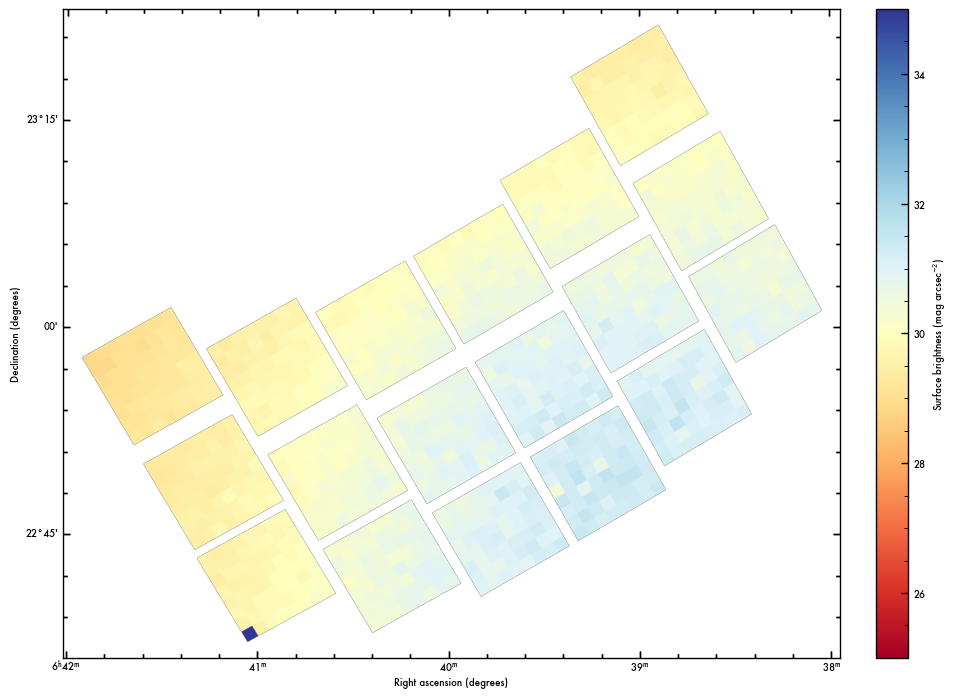

Plot: Stray-light surface brightness flux.
0.00015117770992219452
0.0008535864949226381


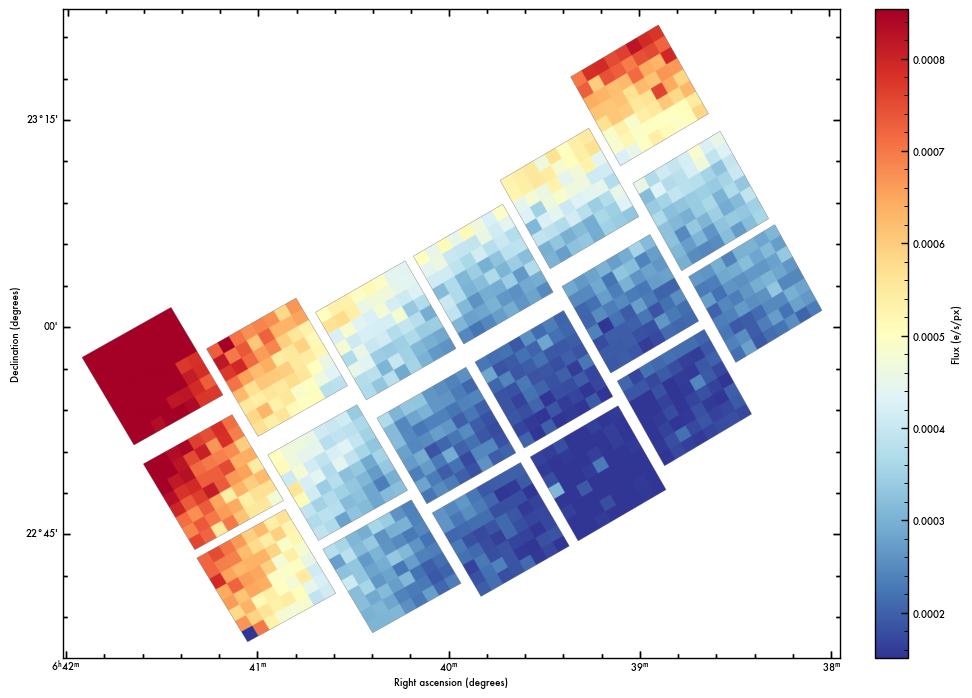

Plot: Main offender map.
1.0
1.0
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]
Simbad cannot find the name of the offender at 101.0 - 24.1
Main stray-light offenders:

100.00% - (101.00, 24.10), m=0.00 - CAT_ID_1


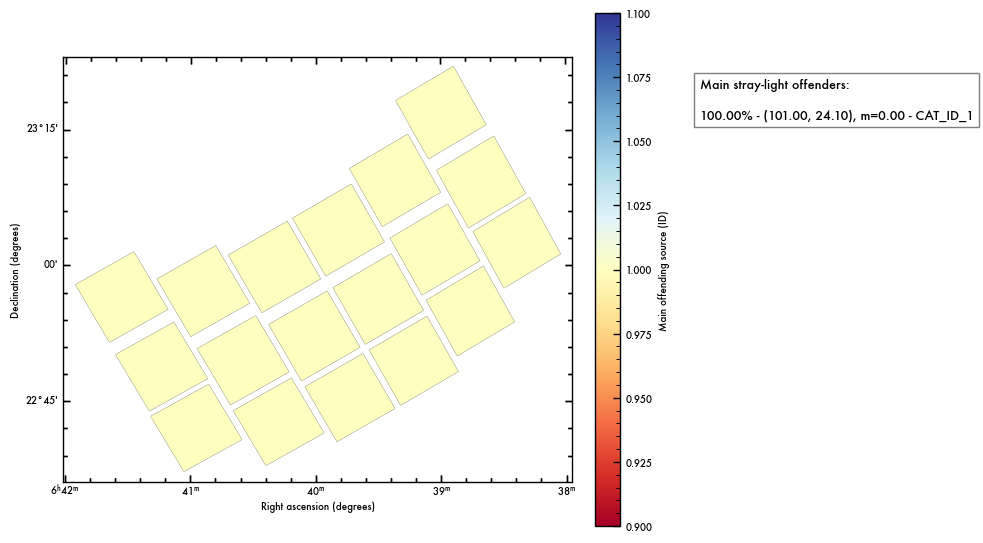

Plot: Source environment map.


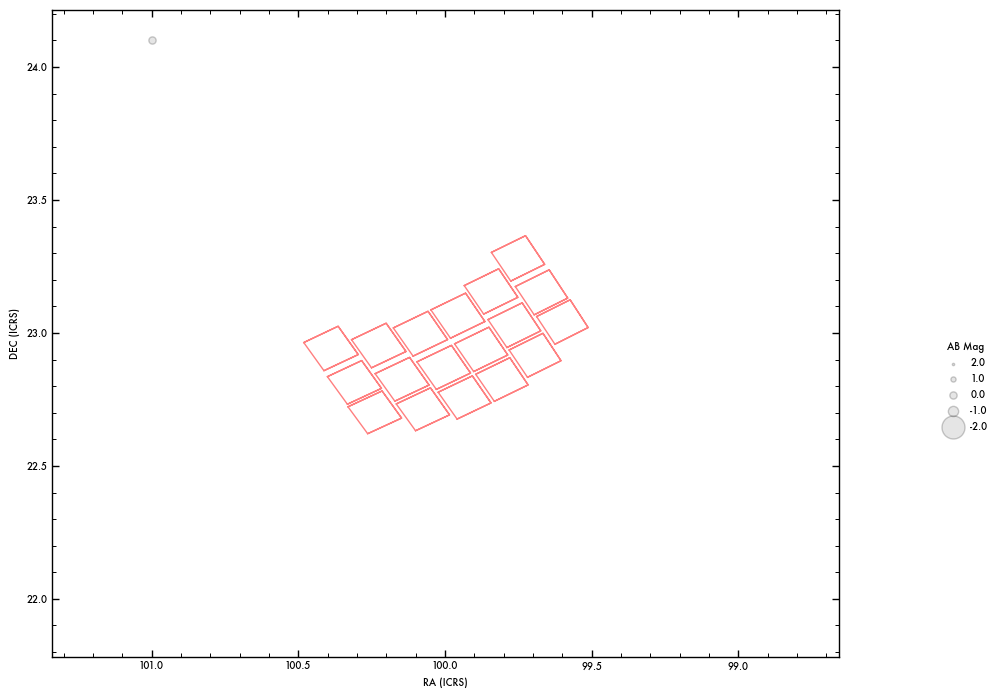

Plot: Location of Main offenders on NDI map.
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]
Simbad cannot find the name of the offender at 101.0 - 24.1
Main stray-light offenders:

100.00% - (101.00, 24.10), m=0.00 - CAT_ID_1
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 100.0 23.0
CRPIX : 636.5 636.5
NAXIS : 1273  1273


IndexError: single positional indexer is out-of-bounds

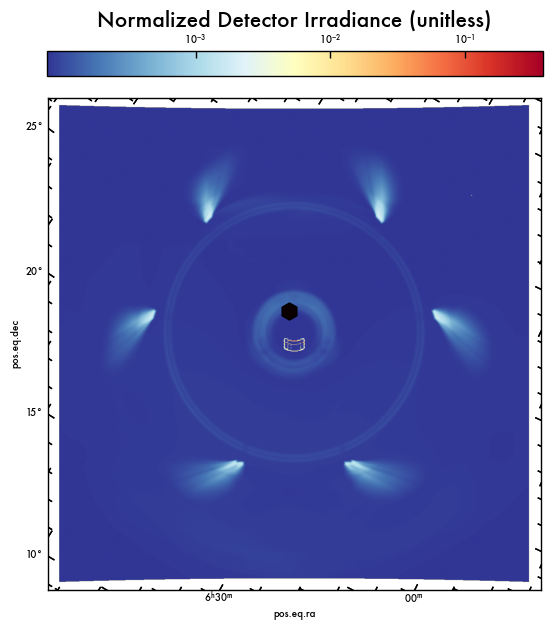

In [30]:
if True:

    # Writing necessary keywords in the output mosaics. 
    keywords = ["RA_TARG", "DEC_TARG", "EXPSTART", "EXPTIME", "FILTER", "WAVEREF", "WAVEMIN", "WAVEMAX", "TELESCOP", "INSTRUME", "DETECTOR"]
    key_values = rs.utils.get_keys_from_header([self.output_name], keywords, ext=0)
    rs.utils.write_parameters_list([self.drz_name], keywords, key_values, ext=0)
    rs.utils.write_parameters_list([self.scaled_drz_name], keywords, key_values, ext=0)
    rs.utils.write_parameters_list([self.scaled_drz_name], ["PIXSCALE"], [[1]], ext=0)
    rs.utils.write_parameters_list([self.scaled_drz_name], ["REBINNED"], [[10]], ext=0)

    rs.utils.write_parameters_list([self.main_offender_output_name], keywords, key_values, ext=0)
    rs.utils.write_parameters_list([self.scaled_main_off], keywords, key_values, ext=0)
    rs.utils.write_parameters_list([self.scaled_main_off], ["PIXSCALE"], [[1]], ext=0)
    rs.utils.write_parameters_list([self.scaled_main_off], ["REBINNED"], [[10]], ext=0)

    # Make the plots. 
    if verbose > 0: print("Plot: Stray-light surface brightness magnitude.")
    fe2mu_png = rs.plots.make_stray_plot(input_name=self.scaled_drz_name,
                                         ext=1, mode="fe2mu",
                                         color_label = "Surface brightness (mag arcsec$^{-2}$)",
                                         figsize=figsize, mu_vmin=mu_vmin, mu_vmax=mu_vmax)

    if verbose > 0: print("Plot: Stray-light surface brightness flux.")
    fe_png = rs.plots.make_stray_plot(input_name=self.scaled_drz_name, ext=1, mode="fe", 
                                      color_label = "Flux (e/s/px)", cmap="RdYlBu_r", figsize=figsize)

    if verbose > 0: print("Plot: Main offender map.")
    main_offender_png = rs.plots.make_stray_plot(input_name=self.scaled_main_off, ext=0, 
                                                 mode="main_offender", 
                                                 catalog=self.source_catalog, 
                                                 color_label = "Main offending source (ID)", 
                                                 figsize=figsize)

    
    if verbose > 0: print("Plot: Source environment map.")
    #try:
    if True:
        stars_around_png = make_stars_around_plot(self.FILENAME, catalog=self.source_catalog, astropywcs_list = self.ASTROPYWCS, 
                                                           RA_TARG=self.RA_TARG, DEC_TARG=self.DEC_TARG, output_name=None, figsize=figsize)
        # def make_stars_around_plot(flt_name, catalog,  astropywcs_list, RA_TARG, DEC_TARG, radius = 0.6, output_name=None, figsize=(10,7)):

    #except:
    #    print(rs.plots.style.YELLOW + "WARNING: Could not make stars around plot. Check if the catalog has the right columns." + rs.plots.style.RESET)
    #    stars_around_png = ""


    if verbose > 0: print("Plot: Location of Main offenders on NDI map.")
    #try:
    if True:
        ndi_mainoff_name = rs.plots.plot_ndi_main_offenders(input_name=self.FILENAME, scaled_main_off=self.scaled_main_off, 
                                                            catalog=self.source_catalog, ndi_level=2, figsize=figsize)
    # except:
    #    print(rs.plots.style.YELLOW + "WARNING: Could not make stars Main offender plot. Check if the catalog has the right columns." + rs.plots.style.RESET)
    #    ndi_mainoff_name = ""

    rs.utils.execute_cmd("magick -adjoin " +\
                        fe2mu_png + " " +\
                        fe_png + " "+\
                        main_offender_png + " " +\
                        stars_around_png + " "+\
                        ndi_mainoff_name + " "+\
                        self.FILENAME.replace(".fits", ".pdf"))



    

In [ ]:

def make_stars_around_plot(flt_name, catalog,  astropywcs_list, RA_TARG, DEC_TARG, radius = 0.6, output_name=None, figsize=(10,7)):
    if output_name is None:
        output_name = flt_name.replace(".fits", "_stars_close.png")
        
    # if True:
    import matplotlib.pyplot as plt
    import numpy as np
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    # Open the original flt file
    # image_identity = rs.utils.exposure_inspector(input_name=flt_name, verbose=False, lite=True)
    
    # Get the detector corners: 
    detector_square_list = []
    for SCIEXT_i in rs.telescopes.Roman.WFI_SCAs:
        detector_corners = rs.detectors.get_detector_corners(wcs=astropywcs_list[SCIEXT_i-1])
        detector_square_list.append(np.concatenate([detector_corners["corners_world"], detector_corners["corners_world"]]))


    # Make a cut in the plot for the stars closer than radius
    target = SkyCoord(RA_TARG*u.deg, DEC_TARG*u.deg, unit="degree", frame="icrs")
    catalog_SkyCoord = SkyCoord(catalog["ra"]*u.deg, catalog["dec"]*u.deg, unit="degree", frame="icrs")
    separation = target.separation(catalog_SkyCoord)

    hybrid_catalog_close = catalog[separation.value<5*radius]

    if len(hybrid_catalog_close)==0:
        print(rs.plots.style.YELLOW + "WARNING: No stars found within " + str(radius) + " degrees. Plotting all stars." + rs.plots.style.RESET)
        hybrid_catalog_close = catalog

    fig, ax = plt.subplots(figsize=figsize)
    
    plot_size, mag_lambda_range, plot_size_range = plot_stars_around(ax=ax, catalog=hybrid_catalog_close, 
                                           max_plot_size=50, min_plot_size=5, alpha=0.2)


    plot_radec_limits = rs.gaia.find_ra_dec_constraints(ra=RA_TARG, dec=DEC_TARG, radius=radius)
    for detector_square in detector_square_list:
        plt.plot(detector_square[:,0], detector_square[:,1], alpha=0.5, color="red")
    ax.set_xlim((plot_radec_limits["ra_max"], plot_radec_limits["ra_min"]))
    ax.set_ylim((plot_radec_limits["dec_min"], plot_radec_limits["dec_max"]))

    # Make the legend 
    for i in range(len(mag_lambda_range) - 1, -1, -1):
        ax.scatter(-9999, -9999, transform=ax.transAxes, 
                   s=plot_size_range[i], marker="o", 
                   facecolor="grey", edgecolor="black",
                   alpha=0.2, label=str(mag_lambda_range[i])) 
    ax.legend(loc="best", title="AB Mag", fancybox=True, edgecolor="white", bbox_to_anchor=(1.2, 0.5))
    fig.tight_layout()
    plt.savefig(output_name, dpi=300)

    plt.show()
    return(output_name)



def plot_stars_around(ax, catalog, max_plot_size=50, min_plot_size=5, alpha=0.2):
    # Auxiliary function to merge some plotting steps in the stray-ligth mapping
    mag_lambda = catalog["mag_lambda"]

    if len(mag_lambda[np.isfinite(mag_lambda)]) == 1:
        the_only_mag = mag_lambda[np.isfinite(mag_lambda)][0]
        plot_size = (max_plot_size + min_plot_size)/2
        mag_lambda_range = np.array([the_only_mag-2, the_only_mag-1, the_only_mag, the_only_mag+1, the_only_mag+2])
        plot_size_range = np.array([10*plot_size, 2*plot_size, plot_size, 0.5*plot_size, 0.1*plot_size])
        
        ra_stars = np.array(catalog["ra"][np.isfinite(mag_lambda)])
        dec_stars = np.array(catalog["dec"][np.isfinite(mag_lambda)])
        ax.scatter(ra_stars, dec_stars, marker="o", facecolor="grey", edgecolor="black",
                   alpha=alpha, s=plot_size)
        ax.set_xlabel("RA (ICRS)")
        ax.set_ylabel("DEC (ICRS)")
        return(plot_size, mag_lambda_range, plot_size_range)

    flux_for_plot = 10**(0.4*(8.9-np.array(catalog["mag_lambda"])))
    ra_stars = np.array(catalog["ra"])
    dec_stars = np.array(catalog["dec"])
    # Plot the planets separately #
    SSO_list_plain = ["Sun", "Moon", "Earth", "Mercury",
                      "Venus", "Mars", "Jupiter", "Saturn",
                      "Uranus", "Neptune", "Pluto"]
    SSO_list_symbols = [u'$\u2609$', u'$\u263D$', u'$\u1F728$',  u'$\u263F$',
                        u'$\u2640$', u'$\u2642$',u'$\u2643$', u'$\u2644$',
                        u'$\u26E2$', u'$\u2646$',  u'$\u2647$']

    #print(bn.nanmin(ra_stars))
    #print(bn.nanmax(ra_stars))
    #print(bn.nanmin(dec_stars))
    #print(bn.nanmax(dec_stars))

    for i, SSO_list_plain_i in zip(range(len(SSO_list_plain)), SSO_list_plain):

        try:
            planet_i = np.where(catalog["source_id"]==SSO_list_plain_i)[0][0]
            #plt.text(ra_stars[planet_i], dec_stars[planet_i], s=SSO_list_symbols[i])
            plt.scatter(ra_stars[planet_i], dec_stars[planet_i], marker=SSO_list_symbols[i], s=1000)
            flux_for_plot[planet_i] = np.nan
            ra_stars[planet_i] = np.nan
            dec_stars[planet_i] = np.nan

        except:
            print("SSO body: " + SSO_list_plain_i + " not found. Skipping")

    max_flux = np.nanpercentile(flux_for_plot, 99)
    min_flux = np.nanpercentile(flux_for_plot, 1)

    # Idea: Plot the main stars with a different color.
    plot_size = flux_for_plot*(max_plot_size-min_plot_size)/(max_flux-min_flux)+0.1
    ax.scatter(ra_stars, dec_stars, marker="o", facecolor="grey", edgecolor="black",
                 alpha=alpha, s=plot_size)
    ax.set_xlabel("RA (ICRS)")
    ax.set_ylabel("DEC (ICRS)")


    ### Give the plot sizes and representative magnitudes. 
    mag_lambda_range = np.unique(mag_lambda[np.isfinite(mag_lambda)].astype("int"))
    from scipy import interpolate
    plot_size_interpolator = interpolate.interp1d(x=mag_lambda[np.isfinite(mag_lambda)],
                                              y=plot_size, kind="linear",
                                              fill_value="extrapolate")
    plot_size_range = plot_size_interpolator(mag_lambda_range)

    return(plot_size,mag_lambda_range, plot_size_range)

In [ ]:
self.source_catalog_filename

In [ ]:
self.SCIEXTS

In [ ]:
self = custom_exposure

if True:
    if True:
        step = 100
        grid_method="random"
    # def make_zodiacal(self, step=100):

        for w in self.ASTROPYWCS:
            detector_grid = rs.detectors.make_detector_grid(w=w, step=step, mode=grid_method)
    
            # Zodipy queries must go in um so we need to multiply by 1E+7 the m above
            obspos = np.array([exposure_identity["XYZ_HELIO_POS"][0][0].value,
                               exposure_identity["XYZ_HELIO_POS"][1][0].value,
                               exposure_identity["XYZ_HELIO_POS"][2][0].value])*u.AU

            zody_MJysr = zodipy_zody(ra=detector_grid["grid_world"][0],
                                     dec=detector_grid["grid_world"][1],
                                     wavelength=rebinned_wavelength.to("um").value,
                                     weights=rebinned_transmission,
                                     expstart=expstart,
                                     obspos=obspos)
